# 03 — EDA: Spatial Join, Supply Indicators, and Equity Narrative

Rewritten from scratch against the current proposal (Section 5.2 and 7). Builds on
02_data_cleaning.ipynb's outputs, which are loaded fresh below so this notebook runs
independently.

Produces: eⱼ (existing EVSE count), Sᵢᵉᶠᶠ (=Σur_j), ūᵢ (mean utilisation), has_evse_i,
the two-condition charging desert split, Fig A/B/C, the income-score vs Sᵢᵉᶠᶠ correlation,
and the join_august2025.csv temporal/power exploration.

## 0. Setup and reload cleaned data

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
from scipy.stats import pearsonr

BASE = "/Users/alexia/Documents/CASA/Dissertation"

census_london = pd.read_csv(os.path.join(BASE, "05_processed/census_london_clean.csv"))
imd_london    = pd.read_csv(os.path.join(BASE, "05_processed/imd_london_clean.csv"))
osev_london   = pd.read_csv(os.path.join(BASE, "05_processed/osev_london_clean.csv"))
zapmap_clean  = pd.read_csv(os.path.join(BASE, "05_processed/zapmap_clean.csv"), parse_dates=["charging_start"])
evse_ur       = pd.read_csv(os.path.join(BASE, "05_processed/evse_ur_clean.csv"))

# location_id -> evse_id mapping for ALL registered EVSEs (restricted data), not just the
# 10,465 that had >=1 session this week — needed for eⱼ, ūᵢ, has_evse_i to be correct
gla_evse_join = pd.read_csv(os.path.join(BASE, "03_data/restricted/gla/gla_location_evse_join.csv"))

figures_dir = os.path.join(BASE, "06_outputs/figures")
os.makedirs(figures_dir, exist_ok=True)

print("Datasets reloaded.")
print(f"census_london: {census_london.shape}, imd_london: {imd_london.shape}")
print(f"osev_london: {osev_london.shape}, zapmap_clean: {zapmap_clean.shape}")
print(f"evse_ur: {evse_ur.shape}, gla_evse_join: {gla_evse_join.shape}")
print(f"Unique evse_id registered (gla_evse_join): {gla_evse_join['evse_id'].nunique()}")
print(f"Unique evse_id with >=1 session this week:  {evse_ur['evse_id'].nunique()}")

Datasets reloaded.
census_london: (4994, 8), imd_london: (4994, 10)
osev_london: (23015, 11), zapmap_clean: (63105, 20)
evse_ur: (10465, 6), gla_evse_join: (38514, 2)
Unique evse_id registered (gla_evse_join): 38375
Unique evse_id with >=1 session this week:  10465


In [2]:
# Load LSOA 2021 boundary geometries (ONS Open Geography, Generalised Clipped V5)
lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

# Restrict to the 4,994 Greater London LSOAs already confirmed in census_london
# NOTE: assumes the boundary file's LSOA code column is 'LSOA21CD' (ONS standard) —
# check lsoa_boundaries.columns if this KeyErrors and adjust the name below.
london_codes = set(census_london["lsoa_code"])
lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(london_codes)].copy()
lsoa_london = lsoa_london.rename(columns={"LSOA21CD": "lsoa_code"})[["lsoa_code", "geometry"]]

print(f"LSOA boundaries matched: {len(lsoa_london)} / {len(london_codes)} expected")

LSOA boundaries matched: 4994 / 4994 expected


## 1. Build the full EVSE registry and spatial-join to LSOA

In [3]:
# Every evse_id registered in gla_location_evse_join.csv, not just the ones with a
# session this week. Session EVSEs get their ur_j from evse_ur_clean.csv (already
# deduplicated, interval-merged, and window-clipped in 02_data_cleaning — do not
# recompute ur_j here). Zero-session EVSEs get ur_j = 0 (declared assumption: absence
# from sessions may reflect genuine zero usage, incomplete reporting, or a join mismatch).
all_registered_evse = gla_evse_join[["location_id", "evse_id"]].drop_duplicates()

full_evse = all_registered_evse.merge(evse_ur[["evse_id", "ur_j"]], on="evse_id", how="left")
full_evse["ur_j"] = full_evse["ur_j"].fillna(0.0)
full_evse["has_session"] = full_evse["ur_j"] > 0

print("=== Full EVSE registry ===")
print("Total registered EVSEs:            ", len(full_evse))
print("With >=1 session this week:        ", full_evse["has_session"].sum())
print("Zero-session (ur_j set to 0):      ", (~full_evse["has_session"]).sum())
print()
print(full_evse["ur_j"].describe())

=== Full EVSE registry ===
Total registered EVSEs:             38375
With >=1 session this week:         10465
Zero-session (ur_j set to 0):       27910

count    38375.000000
mean         0.062623
std          0.177115
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000099
max          0.999504
Name: ur_j, dtype: float64


In [4]:
# Attach coordinates: session EVSEs use their own session-derived lat/lng (from
# evse_ur_clean.csv); zero-session EVSEs have no session records at all, so they
# inherit their location's coordinates from OpenStreetEV_GLA via location_id.
session_coords  = evse_ur[["evse_id", "latitude", "longitude"]]
location_coords = osev_london[["location_id", "latitude", "longitude"]].drop_duplicates(subset=["location_id"])

full_evse_panel = full_evse.merge(session_coords, on="evse_id", how="left")
full_evse_panel = full_evse_panel.merge(location_coords, on="location_id", how="left", suffixes=("", "_loc"))
full_evse_panel["latitude"]  = full_evse_panel["latitude"].fillna(full_evse_panel["latitude_loc"])
full_evse_panel["longitude"] = full_evse_panel["longitude"].fillna(full_evse_panel["longitude_loc"])
full_evse_panel = full_evse_panel.drop(columns=["latitude_loc", "longitude_loc"])

n_missing = full_evse_panel[["latitude", "longitude"]].isna().any(axis=1).sum()
print("EVSE panel shape:", full_evse_panel.shape)
print("Still missing coordinates (location_id not in OpenStreetEV_GLA either):", n_missing)

full_evse_panel_valid = full_evse_panel.dropna(subset=["latitude", "longitude"]).copy()
if n_missing > 0:
    print(f"Dropping {n_missing} EVSEs with no coordinates from either source before the spatial join.")

EVSE panel shape: (38375, 6)
Still missing coordinates (location_id not in OpenStreetEV_GLA either): 0


In [5]:
# Spatial join: EVSE points (WGS84) -> LSOA polygons (EPSG:27700)
evse_gdf = gpd.GeoDataFrame(
    full_evse_panel_valid,
    geometry=gpd.points_from_xy(full_evse_panel_valid["longitude"], full_evse_panel_valid["latitude"]),
    crs="EPSG:4326",
).to_crs(epsg=27700)

evse_joined = gpd.sjoin(evse_gdf, lsoa_london, how="left", predicate="within").drop(columns=["index_right"])

matched = evse_joined["lsoa_code"].notna().sum()
print(f"EVSEs matched to a London LSOA: {matched} / {len(evse_joined)}")

EVSEs matched to a London LSOA: 38375 / 38375


## 2. Aggregate eⱼ, Sᵢᵉᶠᶠ, ūᵢ, has_evse_i to LSOA level

In [6]:
# eⱼ         = count of registered EVSEs (existing supply parameter -> C1 in 05)
# Sᵢᵉᶠᶠ      = sum(ur_j)  — realised charging service index (EDA + post-hoc evaluation only)
# ūᵢ         = mean(ur_j) — feeds Uᵢ = 1 + ūᵢ in 04_demand_estimation
# has_evse_i = eⱼ > 0     — governs the Uᵢ neutral-treatment rule
evse_matched = evse_joined.dropna(subset=["lsoa_code"])

lsoa_evse_agg = evse_matched.groupby("lsoa_code").agg(
    ej=("evse_id", "count"),
    seff=("ur_j", "sum"),
    ubar_i=("ur_j", "mean"),
).reset_index()

# Merge onto the full 4,994 London LSOA list. LSOAs with no registered EVSE get
# eⱼ = 0, Sᵢᵉᶠᶠ = 0. ūᵢ is left as NaN for these — "no EVSE" is not the same thing as
# "0% utilisation", and Uᵢ's neutral-treatment rule (Uᵢ = 1) is applied explicitly in
# 04_demand_estimation using has_evse_i, not by silently defaulting ūᵢ to 0 here.
seff_london = census_london[["lsoa_code", "lsoa_name"]].merge(lsoa_evse_agg, on="lsoa_code", how="left")
seff_london["ej"] = seff_london["ej"].fillna(0).astype(int)
seff_london["seff"] = seff_london["seff"].fillna(0.0)
seff_london["has_evse_i"] = seff_london["ej"] > 0

print("=== eⱼ / Sᵢᵉᶠᶠ / ūᵢ / has_evse_i summary ===")
print(f"LSOAs with has_evse_i = True:  {seff_london['has_evse_i'].sum()}")
print(f"LSOAs with has_evse_i = False: {(~seff_london['has_evse_i']).sum()}")
print()
print("eⱼ stats:");        print(seff_london["ej"].describe())
print()
print("Sᵢᵉᶠᶠ stats:");     print(seff_london["seff"].describe())
print()
print("ūᵢ stats (has_evse_i = True only):")
print(seff_london.loc[seff_london["has_evse_i"], "ubar_i"].describe())

output_path = os.path.join(BASE, "05_processed/seff_london.csv")
seff_london.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

=== eⱼ / Sᵢᵉᶠᶠ / ūᵢ / has_evse_i summary ===
LSOAs with has_evse_i = True:  3493
LSOAs with has_evse_i = False: 1501

eⱼ stats:
count    4994.000000
mean        7.684221
std        16.164393
min         0.000000
25%         0.000000
50%         4.000000
75%        10.000000
max       732.000000
Name: ej, dtype: float64

Sᵢᵉᶠᶠ stats:
count    4994.000000
mean        0.481208
std         1.090062
min         0.000000
25%         0.000000
50%         0.000099
75%         0.603497
max        12.781944
Name: seff, dtype: float64

ūᵢ stats (has_evse_i = True only):
count    3493.000000
mean        0.089784
std         0.155469
min         0.000000
25%         0.000000
50%         0.006473
75%         0.120809
max         0.962401
Name: ubar_i, dtype: float64

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/seff_london.csv


## 3. Charging desert identification — Condition A vs Condition B

In [7]:
# Condition A — true desert: zero registered EVSEs (has_evse_i = False). No infrastructure
# exists at all, regardless of Sᵢᵉᶠᶠ.
# Condition B — underutilised supply: EVSEs exist but Sᵢᵉᶠᶠ ≈ 0 (essentially idle). Opposite
# policy meaning to Condition A: oversupply/misplacement, not absence of infrastructure.
condition_a = ~seff_london["has_evse_i"]
condition_b = seff_london["has_evse_i"] & (seff_london["seff"] < 0.01)

seff_london["desert_condition"] = np.select(
    [condition_a, condition_b],
    ["A_true_desert", "B_underutilised"],
    default="normal",
)

print(seff_london["desert_condition"].value_counts())
print()
print(f"Condition A (true desert):        {condition_a.sum()} LSOAs")
print(f"Condition B (underutilised, has EVSE but Sᵢᵉᶠᶠ≈0): {condition_b.sum()} LSOAs")

seff_london.to_csv(os.path.join(BASE, "05_processed/seff_london.csv"), index=False)

desert_condition
normal             1909
B_underutilised    1584
A_true_desert      1501
Name: count, dtype: int64

Condition A (true desert):        1501 LSOAs
Condition B (underutilised, has EVSE but Sᵢᵉᶠᶠ≈0): 1584 LSOAs


## 4. EDA narrative: Fig A -> Fig B -> Fig C

Three linked choropleths carry the narrative: supply density (Fig A) -> actual usage
(Fig B) -> deprivation (Fig C) -> motivating equity-aware allocation rather than density
or usage alone (proposal Section 7).

### Fig A — number of registered EVSEs (eⱼ) per LSOA

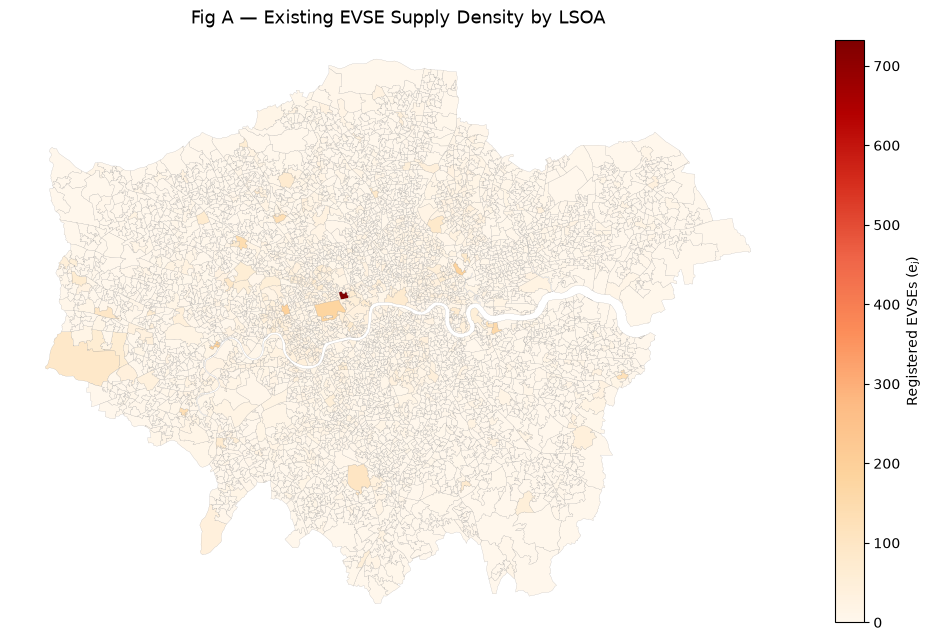

Saved: fig_a_evse_count.png


In [8]:
fig_a_map = lsoa_london.merge(seff_london[["lsoa_code", "ej"]], on="lsoa_code", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
fig_a_map.plot(column="ej", cmap="OrRd", linewidth=0.1, edgecolor="grey",
               legend=True, ax=ax, legend_kwds={"label": "Registered EVSEs (eⱼ)", "shrink": 0.6})
ax.set_title("Fig A — Existing EVSE Supply Density by LSOA", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_a_evse_count.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_a_evse_count.png")

### Fig B — mean realised utilisation (ūᵢ), "been-used" map

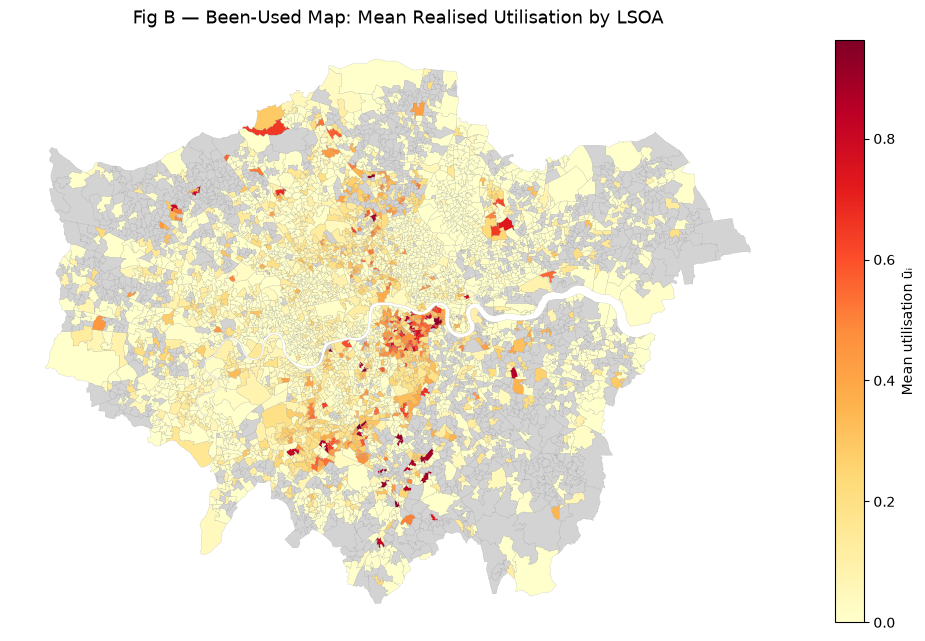

Saved: fig_b_utilisation.png
Grey (no registered EVSE) LSOAs: 1501


In [9]:
# LSOAs with no registered EVSE (has_evse_i = False) are shown in grey/NA, not as ur=0 —
# absence of infrastructure is a different thing from zero utilisation of existing infrastructure.
fig_b_map = lsoa_london.merge(seff_london[["lsoa_code", "ubar_i", "has_evse_i"]], on="lsoa_code", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
fig_b_map.plot(column="ubar_i", cmap="YlOrRd", linewidth=0.1, edgecolor="grey",
               legend=True, ax=ax, missing_kwds={"color": "lightgrey", "label": "No registered EVSE"},
               legend_kwds={"label": "Mean utilisation ūᵢ", "shrink": 0.6})
ax.set_title("Fig B — Been-Used Map: Mean Realised Utilisation by LSOA", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_b_utilisation.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_b_utilisation.png")
print(f"Grey (no registered EVSE) LSOAs: {(~seff_london['has_evse_i']).sum()}")

### Fig C — income deprivation (income_score) per LSOA

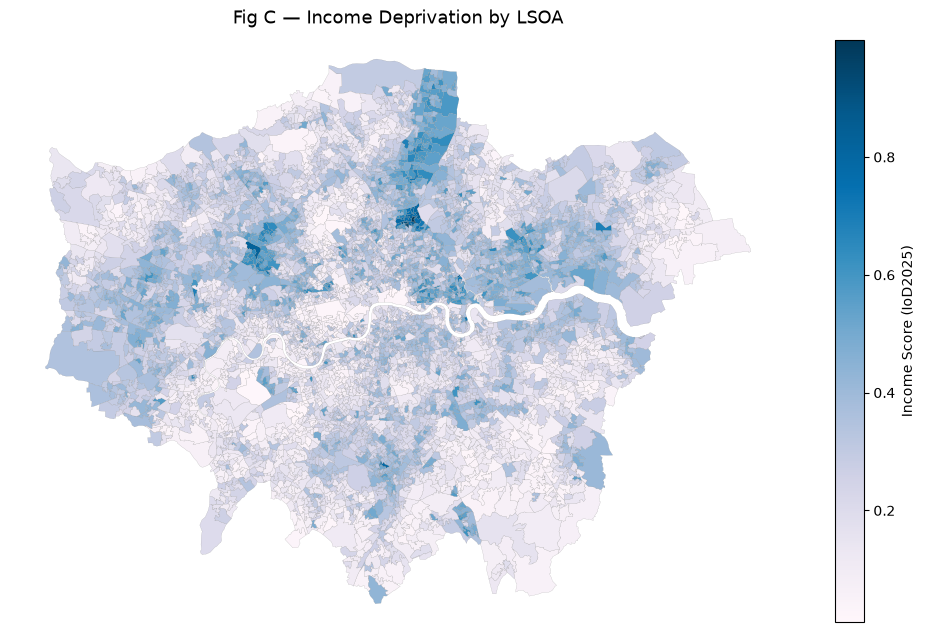

Saved: fig_c_income_deprivation.png


In [10]:
fig_c_map = lsoa_london.merge(imd_london[["lsoa_code", "income_score"]], on="lsoa_code", how="left")

fig, ax = plt.subplots(figsize=(10, 10))
fig_c_map.plot(column="income_score", cmap="PuBu", linewidth=0.1, edgecolor="grey",
               legend=True, ax=ax, legend_kwds={"label": "Income Score (IoD2025)", "shrink": 0.6})
ax.set_title("Fig C — Income Deprivation by LSOA", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_c_income_deprivation.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_c_income_deprivation.png")

## 5. Correlation: income score vs Sᵢᵉᶠᶠ

In [11]:
# Normalise Sᵢᵉᶠᶠ by household count (Hᵢ) — consistent with the household-based demand
# framework (Hᵢ × Cᵢ), rather than the old population-based "per 1,000 residents" framing.
corr_table = (
    census_london[["lsoa_code", "lsoa_name", "Hi"]]
    .merge(imd_london[["lsoa_code", "income_score", "income_decile"]], on="lsoa_code")
    .merge(seff_london[["lsoa_code", "ej", "seff", "ubar_i", "has_evse_i"]], on="lsoa_code")
)
corr_table["ej_per_1000_hh"]   = corr_table["ej"]   / corr_table["Hi"] * 1000
corr_table["seff_per_1000_hh"] = corr_table["seff"] / corr_table["Hi"] * 1000

pairs = [
    ("income_score", "ej_per_1000_hh",   "Income score vs EVSE count per 1,000 households"),
    ("income_score", "seff_per_1000_hh", "Income score vs Sᵢᵉᶠᶠ per 1,000 households"),
]

print("=== Pearson correlations (continuous income_score, not decile) ===")
for col_x, col_y, label in pairs:
    sub = corr_table.dropna(subset=[col_x, col_y])
    r, p = pearsonr(sub[col_x], sub[col_y])
    print(f"{label}: r = {r:.4f}, p = {p:.4g}, n = {len(sub)}")

output_path = os.path.join(BASE, "05_processed/correlation_results.csv")
pd.DataFrame(
    [(l, *pearsonr(corr_table.dropna(subset=[x, y])[x], corr_table.dropna(subset=[x, y])[y]), len(corr_table.dropna(subset=[x, y])))
     for x, y, l in pairs],
    columns=["pair", "pearson_r", "p_value", "n"]
).to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

=== Pearson correlations (continuous income_score, not decile) ===
Income score vs EVSE count per 1,000 households: r = -0.0527, p = 0.000192, n = 4994
Income score vs Sᵢᵉᶠᶠ per 1,000 households: r = -0.0591, p = 2.962e-05, n = 4994

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/correlation_results.csv


### Optional robustness check (subject to time and diagnostics — proposal Section 7)

Core EDA above does not depend on this step. Only run the full SAR regression if Moran's I
on the correlation residuals shows clear spatial autocorrelation.

In [12]:
# Step 1: OLS residuals from income_score ~ seff_per_1000_hh, then Moran's I on those
# residuals. Only proceed to a full spatial-lag/SAR model if this shows clear clustering.
# Requires: pip install esda libpysal (not assumed installed — run once if needed).
try:
    import libpysal
    from esda.moran import Moran
    import statsmodels.api as sm

    reg_data = corr_table.dropna(subset=["income_score", "seff_per_1000_hh"]).copy()
    X = sm.add_constant(reg_data["income_score"])
    ols = sm.OLS(reg_data["seff_per_1000_hh"], X).fit()
    reg_data["resid"] = ols.resid

    reg_geo = lsoa_london.merge(reg_data[["lsoa_code", "resid"]], on="lsoa_code")
    w = libpysal.weights.Queen.from_dataframe(reg_geo)
    w.transform = "r"
    moran = Moran(reg_geo["resid"].values, w)
    print(f"Moran's I on OLS residuals: {moran.I:.4f}, p = {moran.p_sim:.4f}")
    print()
    if moran.p_sim < 0.05:
        print("Significant residual spatial autocorrelation detected — a full spatial-lag/SAR")
        print("regression is warranted as a robustness check (see proposal Section 7).")
    else:
        print("No significant residual spatial autocorrelation — the plain Pearson r above")
        print("is not confounded by it; a full SAR model is not required.")
except ImportError:
    print("esda/libpysal/statsmodels not installed — skip for now, or `pip install esda libpysal statsmodels`")
    print("and re-run this cell. This step is optional and does not block anything downstream.")

/var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/ipykernel_6066/3309774397.py:15: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(reg_geo)


Moran's I on OLS residuals: 0.3861, p = 0.0010

Significant residual spatial autocorrelation detected — a full spatial-lag/SAR
regression is warranted as a robustness check (see proposal Section 7).


## 6. join_august2025.csv exploration: utilisation distribution, power tier, temporal patterns

### utilisation rate distribution (per-EVSE ur_j, session EVSEs only)

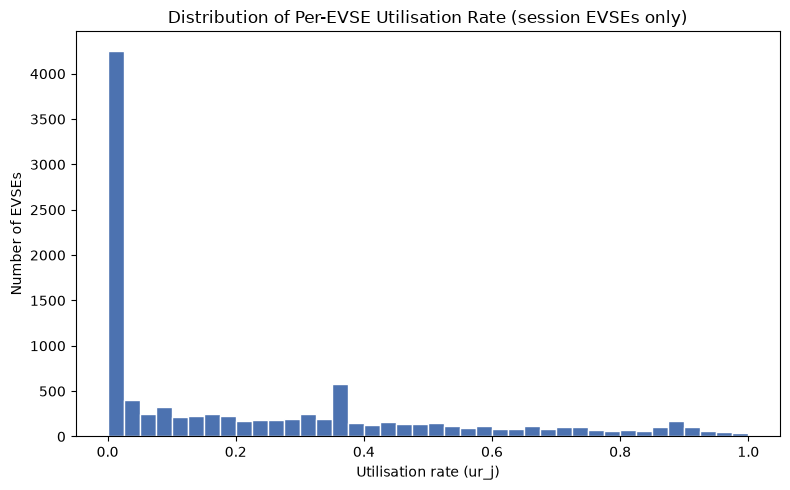

Saved: fig_ur_j_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(evse_ur["ur_j"], bins=40, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Utilisation rate (ur_j)")
ax.set_ylabel("Number of EVSEs")
ax.set_title("Distribution of Per-EVSE Utilisation Rate (session EVSEs only)")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_ur_j_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_ur_j_distribution.png")

### power tier breakdown

power_band
1. Slow           8045
2. Fast (AC)      1477
2. Fast (DC)         2
3. Rapid           385
4. Ultra-rapid     556
Name: count, dtype: int64


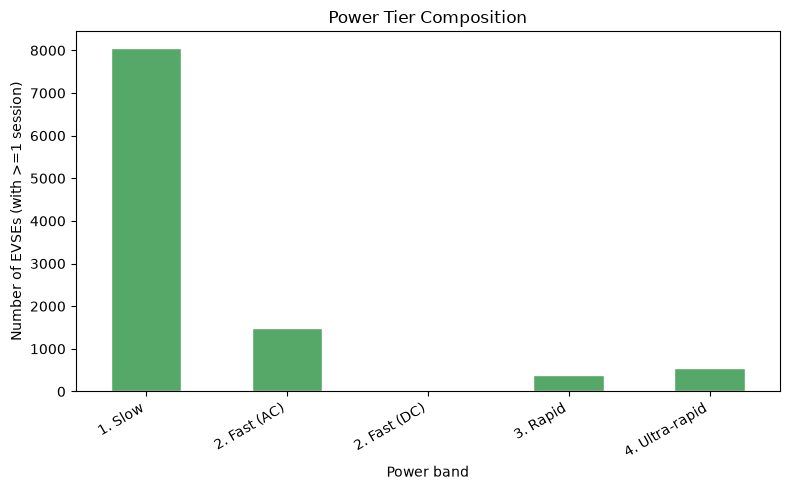

Saved: fig_power_tier.png


In [14]:
evse_power = zapmap_clean.groupby("evse_id")["power_band"].first().reset_index()
power_counts = evse_power["power_band"].value_counts().sort_index()
print(power_counts)

fig, ax = plt.subplots(figsize=(8, 5))
power_counts.plot(kind="bar", ax=ax, color="#55A868", edgecolor="white")
ax.set_xlabel("Power band")
ax.set_ylabel("Number of EVSEs (with >=1 session)")
ax.set_title("Power Tier Composition")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_power_tier.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_power_tier.png")

### temporal patterns — sessions by hour and day of week

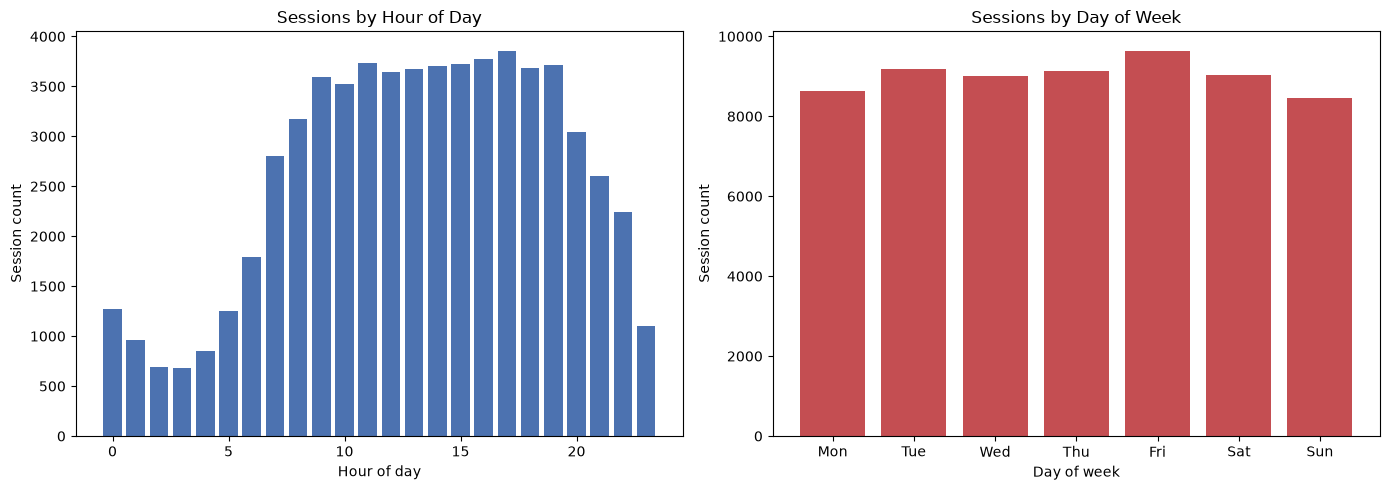

Saved: fig_temporal_patterns.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sessions_by_hour = zapmap_clean.groupby("hour").size()
axes[0].bar(sessions_by_hour.index, sessions_by_hour.values, color="#4C72B0")
axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("Session count")
axes[0].set_title("Sessions by Hour of Day")

dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
sessions_by_dow = zapmap_clean.groupby("dayofweek").size()
axes[1].bar([dow_labels[i] for i in sessions_by_dow.index], sessions_by_dow.values, color="#C44E52")
axes[1].set_xlabel("Day of week"); axes[1].set_ylabel("Session count")
axes[1].set_title("Sessions by Day of Week")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_temporal_patterns.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_temporal_patterns.png")

## 7. Update pipeline_summary.csv

In [16]:
pipeline_summary = pd.read_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"))

updates = {
    "EVSEs matched to LSOA via spatial join": str(matched),
    "eⱼ / Sᵢᵉᶠᶠ / Uᵢ / has_evse_i (LSOA-level)": f"Done — {seff_london['has_evse_i'].sum()} LSOAs with has_evse_i=True",
}
for item, value in updates.items():
    if (pipeline_summary["Item"] == item).any():
        pipeline_summary.loc[pipeline_summary["Item"] == item, "Count"] = value
    else:
        pipeline_summary = pd.concat([pipeline_summary, pd.DataFrame([{"Item": item, "Count": value}])], ignore_index=True)

pipeline_summary.to_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"), index=False)
print(pipeline_summary.to_string(index=False))

                                             Item                                  Count
                    LSOAs loaded (Greater London)                                   4994
Household total (Hi sum, validated vs gor:London)                                3423845
      On-street EVSE locations (OpenStreetEV_GLA)                                  21366
    Session records (join_august2025, post-clean)                                  63105
     Unique EVSEs with ≥1 session (ur_j computed)                                  10465
           EVSEs matched to LSOA via spatial join                                  38375
        eⱼ / Sᵢᵉᶠᶠ / Uᵢ / has_evse_i (LSOA-level) Done — 3493 LSOAs with has_evse_i=True
